<a href="https://colab.research.google.com/github/shubham300701/AI-Meter-Remark-Classification/blob/main/SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Support Vector Machine (SVM)**

Before Running of the Code, Please Upload Two Files in Google Colab Directory
- dataset.csv ( Columns Names "TEXT_REMARKS" and "ACTION_CATEGORY")
- .csv file need to upload for Newer Dataset (with only Two Columns i.e. "TEXT_REMARKS" and "ACTION_CATEGORY"


**Structure of 'dataset.csv':**

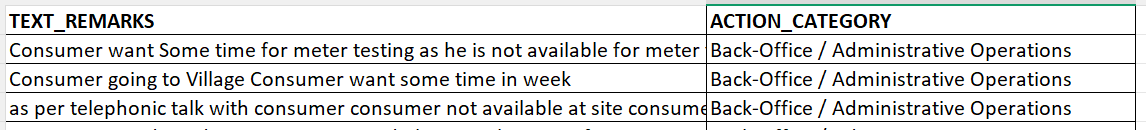

**Structure of newer dataset (in format of .csv):**

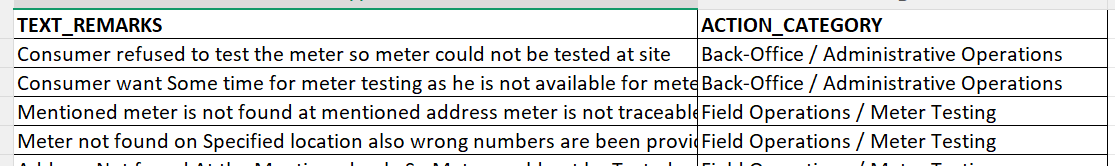


**Structure of Content of Google Colab:**

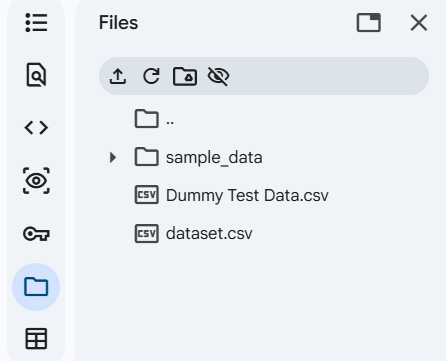

In [2]:
# =========================================================
# METER REMARK CLASSIFICATION SYSTEM (SVM + CSV UPLOAD)
# =========================================================

# FEATURES:
# 1. Train SVM Model
# 2. Save Model + TFIDF
# 3. Live Prediction
# 4. Upload CSV File
# 5. Auto Predict Department
# 6. Generate Output CSV
# =========================================================


# =========================
# 1 IMPORT LIBRARIES
# =========================

import pandas as pd
import pickle

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# =========================
# 2 LOAD DATASET
# =========================

data = pd.read_csv("dataset.csv")

print("Dataset Loaded Successfully")
print(data.head())


# =========================
# 3 INPUT AND OUTPUT
# =========================

X = data['TEXT_REMARKS']
y = data['ACTION_CATEGORY']


# =========================
# 4 TF-IDF VECTORIZATION
# =========================

tfidf = TfidfVectorizer(
    stop_words='english',
    lowercase=True
)

X_tfidf = tfidf.fit_transform(X)

print("\nTF-IDF Vectorization Completed")
print("Total Features:", X_tfidf.shape[1])


# =========================
# 5 TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("\nDataset Split Completed")


# =========================
# 6 TRAIN SVM MODEL
# =========================

svm_model = SVC(
    kernel='linear',
    probability=True
)

svm_model.fit(X_train, y_train)

print("\nSVM Model Training Completed")


# =========================
# 7 MODEL PREDICTION
# =========================

y_pred = svm_model.predict(X_test)


# =========================
# 8 ACCURACY CHECK
# =========================

accuracy = accuracy_score(y_test, y_pred)

print("\n==============================")
print("SVM MODEL ACCURACY")
print("==============================")

print("Accuracy:", accuracy)


# =========================
# 9 CLASSIFICATION REPORT
# =========================

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))


# =========================
# 10 CONFUSION MATRIX
# =========================

print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))


# =========================
# 11 SAVE MODEL
# =========================

pickle.dump(svm_model, open("svm_meter_model.pkl", "wb"))

pickle.dump(tfidf, open("svm_tfidf.pkl", "wb"))

print("\nSVM Model Saved Successfully")


# =========================================================
# 12 LIVE PREDICTION FUNCTION
# =========================================================

def predict_department(text):

    # Convert text into TF-IDF vector
    text_vector = tfidf.transform([str(text)])

    # Predict Department
    prediction = svm_model.predict(text_vector)

    # Prediction Probability
    probability = svm_model.predict_proba(text_vector)

    confidence = probability.max() * 100

    return prediction[0], confidence


# =========================================================
# 13 SINGLE LIVE PREDICTION
# =========================================================

print("\n====================================")
print("Meter Remark AI Classification System")
print("Type 'exit' to stop")
print("====================================")

while True:

    remark = input("\nEnter Meter Testing Remark: ")

    if remark.lower() == "exit":
        break

    department, confidence = predict_department(remark)

    print("\nPredicted Department:", department)

    print("Confidence Score:", round(confidence, 2), "%")


# =========================================================
# 14 BULK CSV FILE PREDICTION WITH EVALUATION
# =========================================================

print("\n====================================")
print("BULK CSV FILE PREDICTION SYSTEM")
print("====================================")

input_file = input("\nEnter CSV File Name: ")

# LOAD CSV
bulk_data = pd.read_csv(input_file)

print("\nCSV Loaded Successfully")
print(bulk_data.head())


# =========================================================
# CHECK REQUIRED COLUMN
# =========================================================

if 'TEXT_REMARKS' not in bulk_data.columns:

    print("\nERROR:")
    print("CSV must contain TEXT_REMARKS column")

else:

    predicted_departments = []
    confidence_scores = []
    confidence_ranges = []
    match_status = []

    # =====================================================
    # PREDICTION LOOP
    # =====================================================

    for index, row in bulk_data.iterrows():

        remark = row['TEXT_REMARKS']

        # Predict
        department, confidence = predict_department(remark)

        # Save Prediction
        predicted_departments.append(department)

        confidence = round(confidence, 2)

        confidence_scores.append(round(confidence, 2))

        # =================================================
        # CONFIDENCE RANGE CLASSIFICATION
        # =================================================

        if confidence >= 90:

            confidence_ranges.append("100-90% Very High")

        elif confidence >= 75:

            confidence_ranges.append("90-75% High")

        elif confidence >= 50:

            confidence_ranges.append("75-50% Medium")

        else:

            confidence_ranges.append("Below 50% Low")

        # =================================================
        # MATCH STATUS
        # =================================================

        if 'ACTION_CATEGORY' in bulk_data.columns:

            actual = row['ACTION_CATEGORY']

            if str(actual).strip() == str(department).strip():

                match_status.append("Correct")

            else:

                match_status.append("Wrong")

        else:

            match_status.append("No Actual Label")

    # =====================================================
    # ADD OUTPUT COLUMNS
    # =====================================================

    bulk_data['PREDICTED_DEPARTMENT'] = predicted_departments

    bulk_data['CONFIDENCE_SCORE'] = confidence_scores

    bulk_data['CONFIDENCE_RANGE'] = confidence_ranges

    bulk_data['MATCH_STATUS'] = match_status

    # =====================================================
    # SAVE OUTPUT CSV
    # =====================================================

    output_file = "Final_Predicted_Output.csv"

    bulk_data.to_csv(output_file, index=False)

    print("\n====================================")
    print("PREDICTION COMPLETED SUCCESSFULLY")
    print("====================================")

    print("\nOutput File Saved As:")
    print(output_file)

    # =====================================================
    # SUMMARY
    # =====================================================

    if 'ACTUAL_DEPARTMENT' in bulk_data.columns:

        correct_count = (bulk_data['MATCH_STATUS'] == "Correct").sum()

        wrong_count = (bulk_data['MATCH_STATUS'] == "Wrong").sum()

        print("\n====================================")
        print("PREDICTION SUMMARY")
        print("====================================")

        print("Correct Predictions :", correct_count)

        print("Wrong Predictions   :", wrong_count)

    print("\nSample Output:\n")

    print(bulk_data.head())


Dataset Loaded Successfully
                                        TEXT_REMARKS  \
0  Consumer want Some time for meter testing as h...   
1  Consumer going to Village Consumer want some t...   
2  as per telephonic talk with consumer consumer ...   
3  No person at side and no response on said phon...   
4  No person at side and no response on said phon...   

                           ACTION_CATEGORY  Unnamed: 2  Unnamed: 3  \
0  Back-Office / Administrative Operations         NaN         NaN   
1  Back-Office / Administrative Operations         NaN         NaN   
2  Back-Office / Administrative Operations         NaN         NaN   
3  Back-Office / Administrative Operations         NaN         NaN   
4  Back-Office / Administrative Operations         NaN         NaN   

   Unnamed: 4  Unnamed: 5  Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  \
0         NaN         NaN         NaN         NaN         NaN         NaN   
1         NaN         NaN         NaN         NaN         Na

**Files in Content After Running the code:**
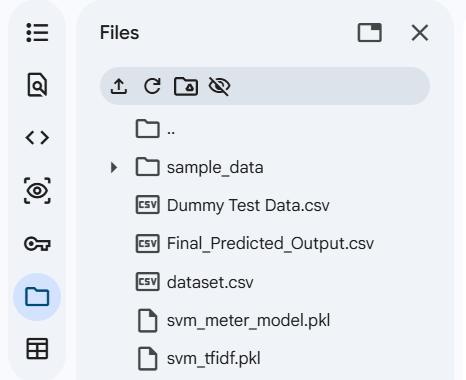

**Structure of  "Final_Predicted_Output.csv":**
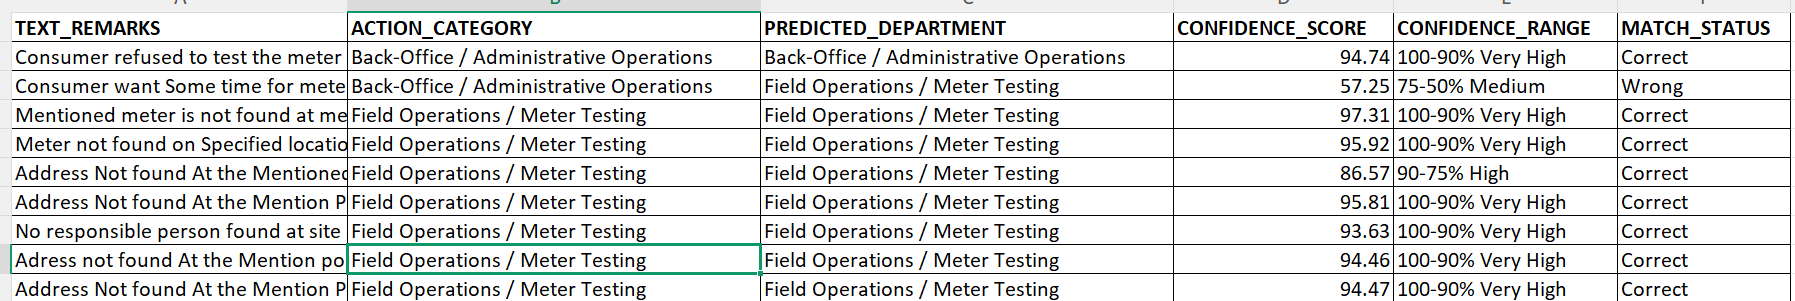

Link: https://colab.research.google.com/drive/16F6FhqMnwT-TKZPjOZyOvqZGl5gL67KV?usp=sharing